# Посмотрим какие данные у нас есть

## Сначала посмотрим на holidays events
Согласно данным на kaggle данный датасет представляет собой информацию о выходных или праздниках в конкретные дни.

In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import xgboost

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [158]:
df_events = pd.read_csv('data/holidays_events.csv')
df_events.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [159]:
df_events.dtypes

date            str
type            str
locale          str
locale_name     str
description     str
transferred    bool
dtype: object

In [160]:
# Сразу разберемся с типами данных, приведем столбец date к формату datetime
df_events['date'] = pd.to_datetime(df_events['date'])

In [161]:
df_events.describe(include="all")

,date,type,locale,locale_name,description,transferred
count,350,350,350,350,350,350
unique,NaN,6,3,24,103,2
top,NaN,Holiday,National,Ecuador,Carnaval,False
freq,NaN,221,174,174,10,338
mean,2015-04-24 00:45:15.428571,NaN,NaN,NaN,NaN,NaN
min,2012-03-02 00:00:00,NaN,NaN,NaN,NaN,NaN
25%,2013-12-23 06:00:00,NaN,NaN,NaN,NaN,NaN
50%,2015-06-08 00:00:00,NaN,NaN,NaN,NaN,NaN
75%,2016-07-03 00:00:00,NaN,NaN,NaN,NaN,NaN
max,2017-12-26 00:00:00,NaN,NaN,NaN,NaN,NaN


In [162]:
df_events['type'].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [163]:
df_events['locale'].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [164]:
df_events['locale_name'].value_counts().head(10)

locale_name
Ecuador      174
Quito         13
Riobamba      12
Guaranda      12
Latacunga     12
Ambato        12
Guayaquil     11
Cuenca         7
Ibarra         7
Manta          6
Name: count, dtype: int64

In [165]:
df_events['description'].value_counts()

description
Carnaval                           10
Fundacion de Cuenca                 7
Fundacion de Ibarra                 7
Fundacion de Manta                  6
Provincializacion de Cotopaxi       6
                                   ..
Traslado Fundacion de Guayaquil     1
Puente Dia de Difuntos              1
Recupero Puente Dia de Difuntos     1
Traslado Primer dia del ano         1
Traslado Fundacion de Quito         1
Name: count, Length: 103, dtype: int64

In [166]:
df_events['transferred'].value_counts()

transferred
False    338
True      12
Name: count, dtype: int64

In [167]:
# Сделаем дату индексом
df_events = df_events.set_index('date')

## Теперь рассмотрим на oil (цены на нефть)

In [168]:
df_oil = pd.read_csv('data/oil.csv')
df_oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [169]:
df_oil.dtypes

date              str
dcoilwtico    float64
dtype: object

In [170]:
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil.dtypes

date          datetime64[us]
dcoilwtico           float64
dtype: object

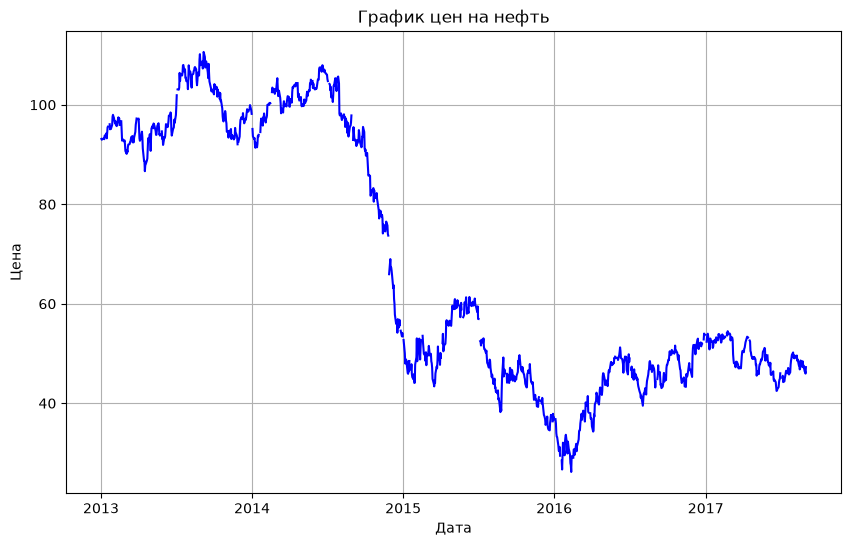

In [171]:
plt.figure(figsize=(10,6))
plt.plot(df_oil['date'], df_oil['dcoilwtico'], linestyle='-', color='blue', label='График цен на нефть')

plt.title('График цен на нефть')
plt.xlabel('Дата')
plt.ylabel('Цена')

plt.grid(True)
plt.show()


In [172]:
df_oil.describe()

,date,dcoilwtico
count,1218,1175.000000
mean,2015-05-02 12:00:00,67.714366
min,2013-01-01 00:00:00,26.190000
25%,2014-03-03 06:00:00,46.405000
50%,2015-05-02 12:00:00,53.190000
75%,2016-06-30 18:00:00,95.660000
max,2017-08-31 00:00:00,110.620000
std,NaN,25.630476


In [173]:
# Почистим пропущенные значения
df_oil = df_oil.sort_values('date')
df_oil = df_oil.set_index('date')
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].interpolate(method='time')


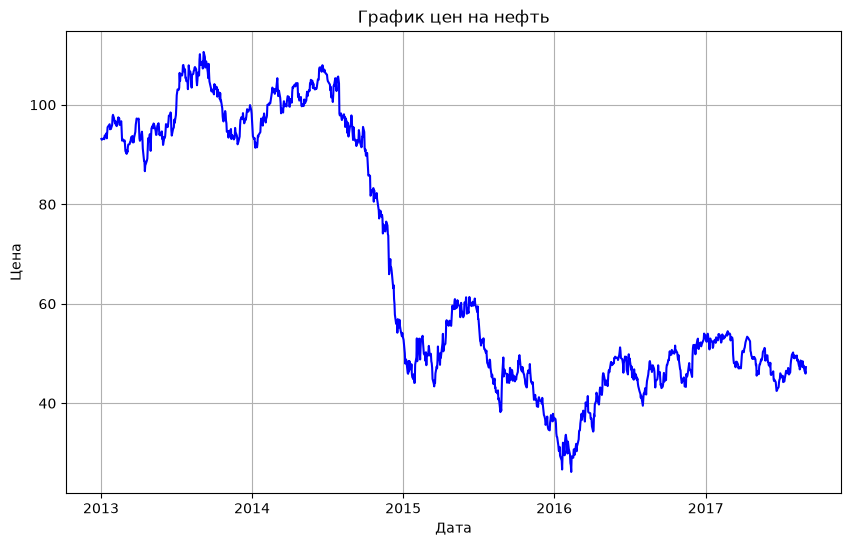

In [174]:
plt.figure(figsize=(10,6))
plt.plot(df_oil.index, df_oil['dcoilwtico'], linestyle='-', color='blue', label='График цен на нефть')

plt.title('График цен на нефть')
plt.xlabel('Дата')
plt.ylabel('Цена')

plt.grid(True)
plt.show()


## Рассмотрим stores (даныне о магазинах)

In [175]:
df_stores = pd.read_csv('data/stores.csv')
df_stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [176]:
df_stores = df_stores.set_index('store_nbr')
df_stores.describe(include='all')

,city,state,type,cluster
count,54,54,54,54.000000
unique,22,16,5,NaN
top,Quito,Pichincha,D,NaN
freq,18,19,18,NaN
mean,NaN,NaN,NaN,8.481481
std,NaN,NaN,NaN,4.693395
min,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,8.500000
75%,NaN,NaN,NaN,13.000000


In [177]:
df_stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 1 to 54
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   city     54 non-null     str  
 1   state    54 non-null     str  
 2   type     54 non-null     str  
 3   cluster  54 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [178]:
# Не знаю, как можно обработать эти данные в текущий момент, поэтому удалю столбец state, т.к. считаю его бесполезным.
df_stores = df_stores.drop(["state"], axis=1)
df_stores.head()

,city,type,cluster
store_nbr,,,
1,Quito,D,13
2,Quito,D,13
3,Quito,D,8
4,Quito,D,9
5,Santo Domingo,D,4


## Рассмотрим transactions (транзакции)

In [179]:
df_transactions = pd.read_csv('data/transactions.csv')
df_transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [180]:
df_transactions['date'] = pd.to_datetime(df_transactions['date'])
df_transactions = df_transactions.set_index('date')

In [181]:
df_transactions.describe(include='all')

,store_nbr,transactions
count,83488.000000,83488.000000
mean,26.939237,1694.602158
std,15.608204,963.286644
min,1.000000,5.000000
25%,13.000000,1046.000000
50%,27.000000,1393.000000
75%,40.000000,2079.000000
max,54.000000,8359.000000


In [182]:
df_transactions.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 83488 entries, 2013-01-01 to 2017-08-15
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   store_nbr     83488 non-null  int64
 1   transactions  83488 non-null  int64
dtypes: int64(2)
memory usage: 1.9 MB


In [183]:
# Посмотрим транзакции по магазинам

stores = df_transactions['store_nbr'].unique()

cols = 4
rows = math.ceil(len(stores) / cols)

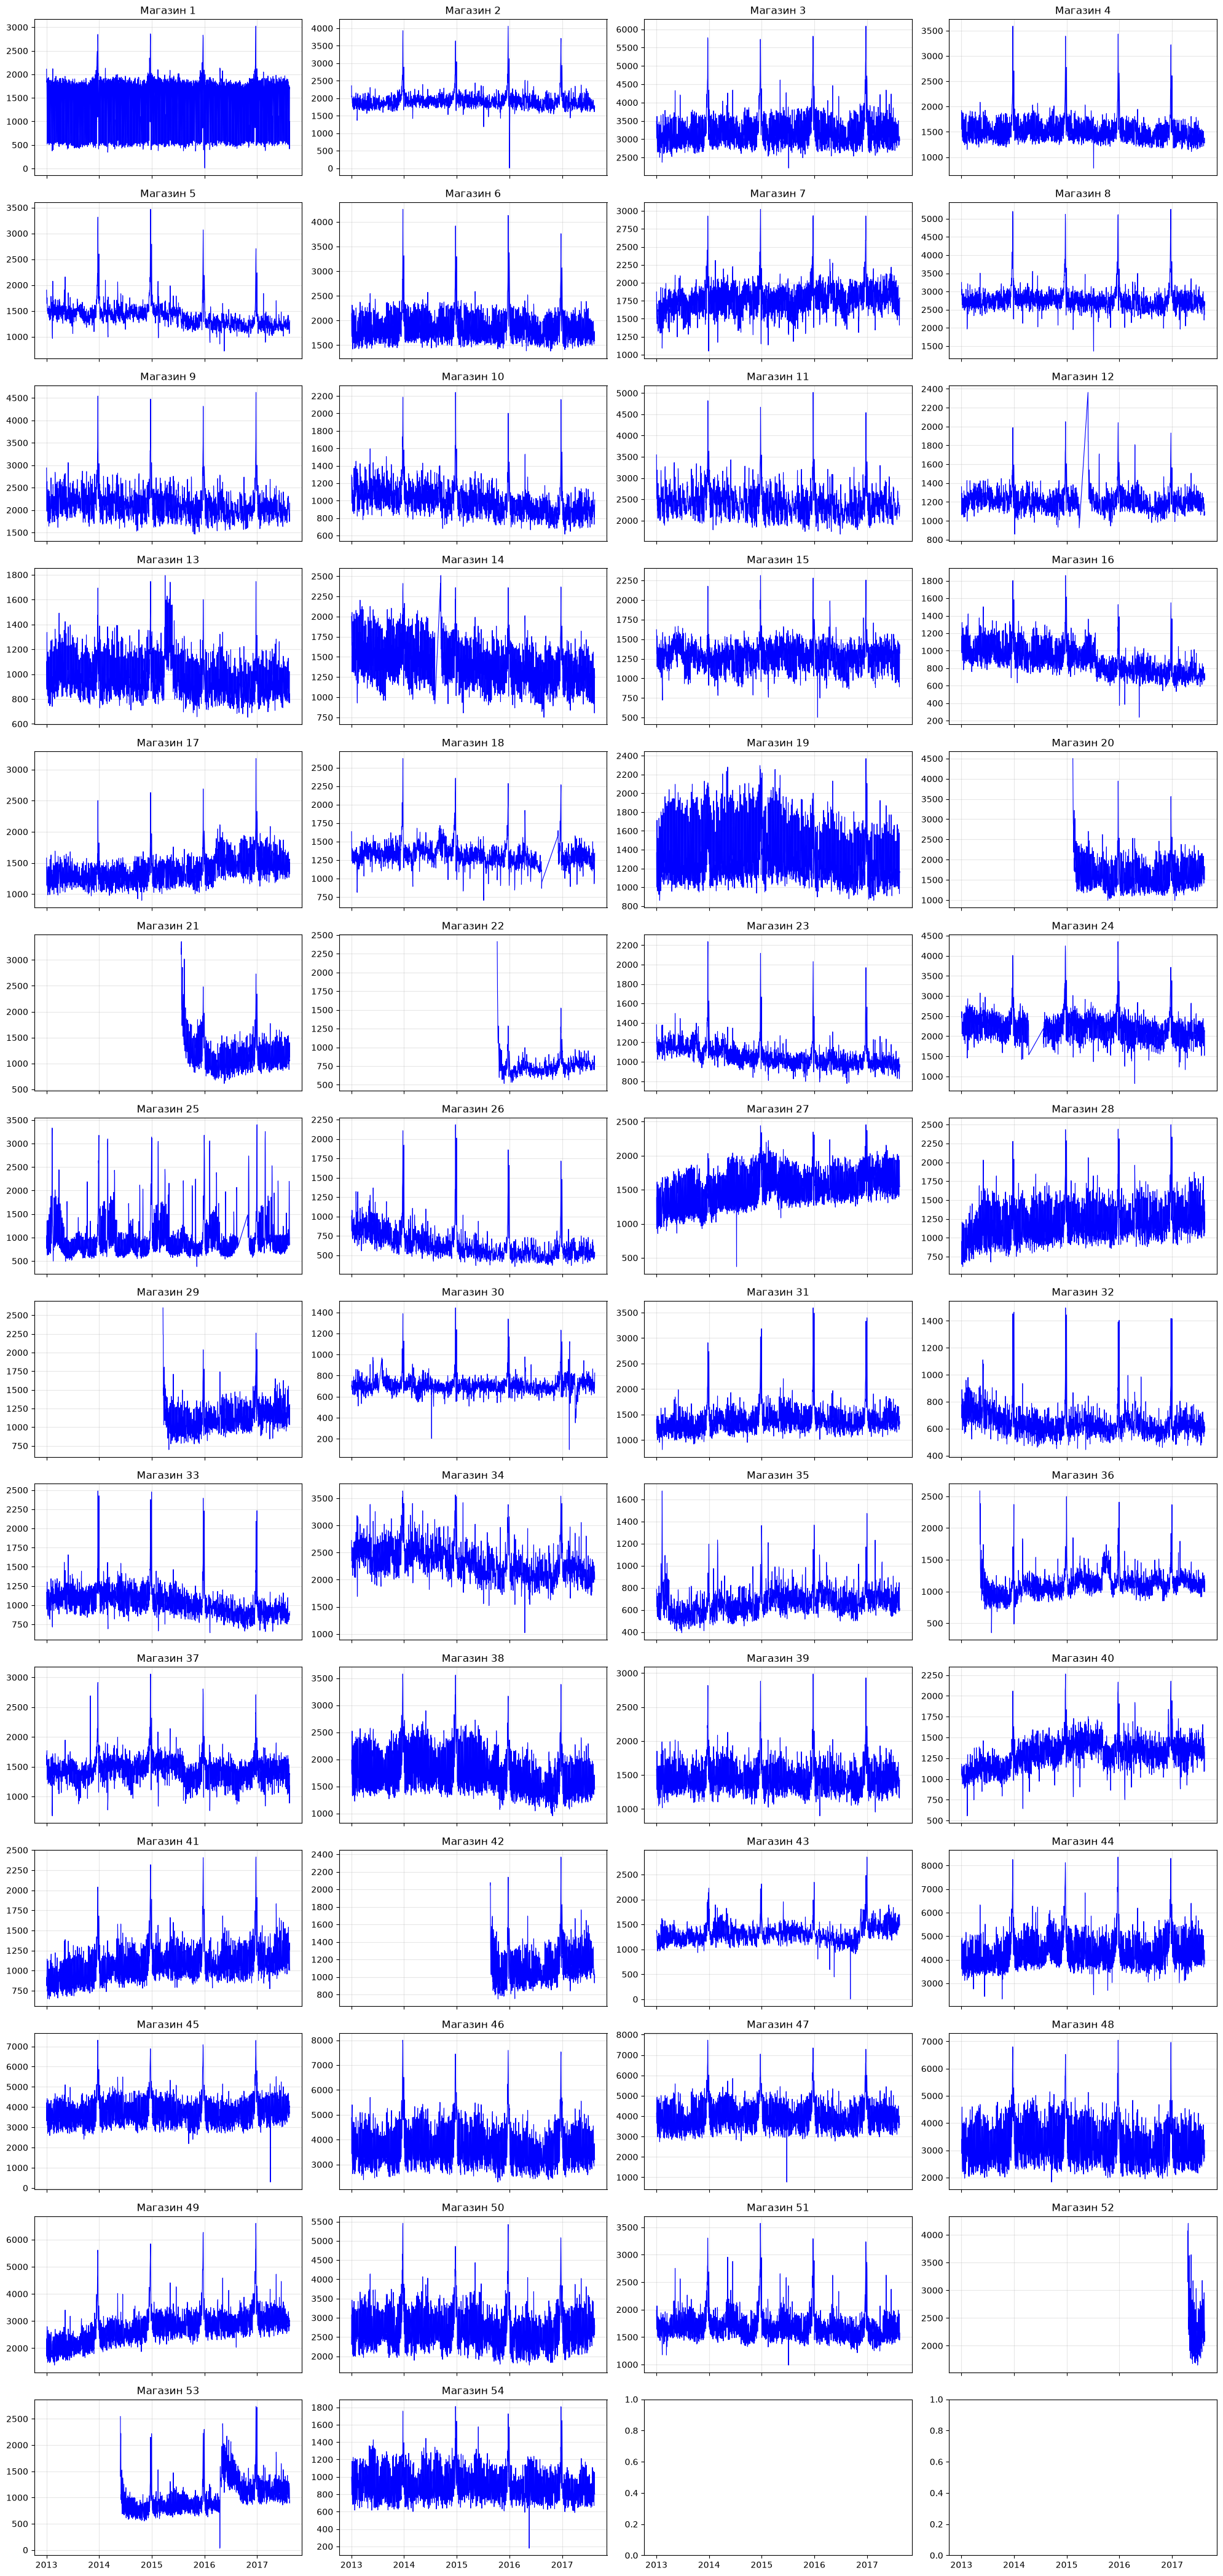

In [184]:
fig, axes = plt.subplots(
    rows,
    cols,
    figsize = (20, rows * 3),
    sharex = True
)

axes = axes.flatten()

for i, (store, data) in enumerate(df_transactions.groupby('store_nbr')):
    axes[i].plot(
        data.index,
        data['transactions'],
        color='blue',
        linewidth = 0.8
    )
    
    axes[i].set_title(f"Магазин {store}")
    axes[i].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()
    

## Объеденим все данные (holidays_events, oil, stores, transactions) из "внешних" источников в один датасет

In [185]:
df_data = pd.merge(df_events.join(df_oil, how='inner').join(df_transactions, how='inner'), 
                   df_stores, how='left', 
                   left_on = 'store_nbr',
                   right_index=True)

df_data.head()


,type_x,locale,locale_name,description,transferred,dcoilwtico,store_nbr,transactions,city,type_y,cluster
date,,,,,,,,,,,
2013-01-01,Holiday,National,Ecuador,Primer dia del ano,False,NaN,25,770,Salinas,D,1
2013-02-11,Holiday,National,Ecuador,Carnaval,False,97.01,1,396,Quito,D,13
2013-02-11,Holiday,National,Ecuador,Carnaval,False,97.01,2,1486,Quito,D,13
2013-02-11,Holiday,National,Ecuador,Carnaval,False,97.01,3,2532,Quito,D,8
2013-02-11,Holiday,National,Ecuador,Carnaval,False,97.01,4,1263,Quito,D,9


In [186]:
df_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9759 entries, 2013-01-01 to 2017-08-15
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type_x        9759 non-null   str    
 1   locale        9759 non-null   str    
 2   locale_name   9759 non-null   str    
 3   description   9759 non-null   str    
 4   transferred   9759 non-null   bool   
 5   dcoilwtico    9758 non-null   float64
 6   store_nbr     9759 non-null   int64  
 7   transactions  9759 non-null   int64  
 8   city          9759 non-null   str    
 9   type_y        9759 non-null   str    
 10  cluster       9759 non-null   int64  
dtypes: bool(1), float64(1), int64(3), str(6)
memory usage: 848.2 KB


## Теперь рассмотрим тренировочные данные.

In [187]:
df = pd.read_csv('data/train.csv').set_index('id')
df.head()

,date,store_nbr,family,sales,onpromotion
id,,,,,
0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,2013-01-01,1,BABY CARE,0.0,0
2,2013-01-01,1,BEAUTY,0.0,0
3,2013-01-01,1,BEVERAGES,0.0,0
4,2013-01-01,1,BOOKS,0.0,0


In [188]:
df.describe(include='all')

,date,store_nbr,family,sales,onpromotion
count,3000888,3.000888e+06,3000888,3.000888e+06,3.000888e+06
unique,1684,NaN,33,NaN,NaN
top,2013-01-01,NaN,AUTOMOTIVE,NaN,NaN
freq,1782,NaN,90936,NaN,NaN
mean,NaN,2.750000e+01,NaN,3.577757e+02,2.602770e+00
std,NaN,1.558579e+01,NaN,1.101998e+03,1.221888e+01
min,NaN,1.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,NaN,1.400000e+01,NaN,0.000000e+00,0.000000e+00
50%,NaN,2.750000e+01,NaN,1.100000e+01,0.000000e+00
75%,NaN,4.100000e+01,NaN,1.958473e+02,0.000000e+00


In [189]:
df.dtypes

date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object

In [190]:
df['date'] = pd.to_datetime(df['date'])

In [191]:
df.dtypes

date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

In [192]:
# Разобьем датасет на тренировучкую и обучающую выборки
x_train, x_test, y_train, y_test = train_test_split(df.drop(['sales'], axis=1), df['sales'], test_size=0.2, random_state=42)

In [193]:
#добавим в тренировочный датасет и в тестовый доп. данные
x_train = pd.merge(x_train, df_data, how='inner', left_on='date', right_index=True)

In [194]:
x_test = pd.merge(x_test, df_data, how='inner', left_on='date', right_index=True)

In [ ]:
print(x_train.columns)
print(x_test.columns)

# Данные подготовлены.

Index(['date', 'store_nbr_x', 'family', 'onpromotion', 'type_x', 'locale',
       'locale_name', 'description', 'transferred', 'dcoilwtico',
       'store_nbr_y', 'transactions', 'city', 'type_y', 'cluster'],
      dtype='str')
Index(['date', 'store_nbr_x', 'family', 'onpromotion', 'type_x', 'locale',
       'locale_name', 'description', 'transferred', 'dcoilwtico',
       'store_nbr_y', 'transactions', 'city', 'type_y', 'cluster'],
      dtype='str')


## Готовим данные для будущего обучения модели

In [201]:
# заменяем datetime
x_test['year'] = x_test['date'].dt.year
x_test['month'] = x_test['date'].dt.month
x_test['day'] = x_test['date'].dt.day
x_test['day_of_week'] = x_test['date'].dt.dayofweek
x_test['hour'] = x_test['date'].dt.hour
x_test = x_test.drop(columns=['date'])


In [203]:
# заменяем datetime
x_train['year'] = x_train['date'].dt.year
x_train['month'] = x_train['date'].dt.month
x_train['day'] = x_train['date'].dt.day
x_train['day_of_week'] = x_train['date'].dt.dayofweek
x_train['hour'] = x_train['date'].dt.hour
x_train = x_train.drop(columns=['date'])


In [204]:
x_test.head()

,store_nbr_x,family,onpromotion,type_x,locale,locale_name,description,transferred,dcoilwtico,store_nbr_y,transactions,city,type_y,cluster,year,month,day,day_of_week,hour
id,,,,,,,,,,,,,,,,,,,
2579933,47,PET SUPPLIES,1,Additional,National,Ecuador,Navidad-4,False,51.44,1,2555,Quito,D,13,2016,12,21,2,0
2579933,47,PET SUPPLIES,1,Additional,National,Ecuador,Navidad-4,False,51.44,2,2923,Quito,D,13,2016,12,21,2,0
2579933,47,PET SUPPLIES,1,Additional,National,Ecuador,Navidad-4,False,51.44,3,5074,Quito,D,8,2016,12,21,2,0
2579933,47,PET SUPPLIES,1,Additional,National,Ecuador,Navidad-4,False,51.44,4,2323,Quito,D,9,2016,12,21,2,0
2579933,47,PET SUPPLIES,1,Additional,National,Ecuador,Navidad-4,False,51.44,5,1982,Santo Domingo,D,4,2016,12,21,2,0


In [205]:
x_train.head()

,store_nbr_x,family,onpromotion,type_x,locale,locale_name,description,transferred,dcoilwtico,store_nbr_y,transactions,city,type_y,cluster,year,month,day,day_of_week,hour
id,,,,,,,,,,,,,,,,,,,
2991984,1,CELEBRATION,0,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False,48.81,1,570,Quito,D,13,2017,8,11,4,0
2991984,1,CELEBRATION,0,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False,48.81,2,1698,Quito,D,13,2017,8,11,4,0
2991984,1,CELEBRATION,0,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False,48.81,3,2991,Quito,D,8,2017,8,11,4,0
2991984,1,CELEBRATION,0,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False,48.81,4,1301,Quito,D,9,2017,8,11,4,0
2991984,1,CELEBRATION,0,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False,48.81,5,1183,Santo Domingo,D,4,2017,8,11,4,0


In [ ]:
# Определяем строковые и числовые переменные
string_cols = x_train.select_dtypes(include=['string']).columns.to_list()
numeric_cols = x_train.select_dtypes(include=['number']).columns.to_list()
x_train.dtypes

store_nbr_x       int64
family              str
onpromotion       int64
type_x              str
locale              str
locale_name         str
description         str
transferred        bool
dcoilwtico      float64
store_nbr_y       int64
transactions      int64
city                str
type_y              str
cluster           int64
year              int32
month             int32
day               int32
day_of_week       int32
hour              int32
dtype: object

In [ ]:
# Инициализируем энкодер и скейлер
ohe = OneHotEncoder()
scaler = RobustScaler()